In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [4]:
DBS_ON_OFF = pd.read_csv('DBS_ON_OFF.csv')

## Delta Clinical Score vs. Delta DBCS

In [7]:


finalScores = [
            'Movement_Vigor_Score',
            'SequenceEffect_Score',
            'Movement_Irregularity_Score',
            'Timming_Score',
            'Pauses_and_Hesitations_Score',
            # 'Timming_Irregularity_Score',
            'Final_Score',
        ]

var = finalScores[5]


wide = DBS_ON_OFF.pivot(index='Subject', columns='DBS')
wide = wide.dropna(subset=pd.MultiIndex.from_product([finalScores, ['ON', 'OFF']]), how='any')
# Compute ON–OFF differences per subject

diff_df = pd.DataFrame({
    'Delta_Item': wide[('Item', 'ON')] - wide[('Item', 'OFF')] ,
    'Delta_Final': wide[(var, 'ON')] - wide[(var, 'OFF')] ,
    'Subject': wide[('SubjectID', 'OFF')]
}).dropna()


# Ensure model variables are numeric (avoid object->categorical expansion in formula)
diff_df['Delta_Item'] = pd.to_numeric(diff_df['Delta_Item'], errors='coerce')
diff_df['Delta_Final'] = pd.to_numeric(diff_df['Delta_Final'], errors='coerce')

# Keep valid rows only
diff_df = diff_df.dropna(subset=['Delta_Item', 'Delta_Final', 'Subject']).copy()

ols_DBS = smf.mixedlm("Delta_Final ~ Delta_Item", diff_df, groups=diff_df["Subject"]).fit()
print(ols_DBS.summary())
print(ols_DBS.pvalues['Delta_Item'])

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta_Final
No. Observations: 38      Method:             REML       
No. Groups:       21      Scale:              1.8648     
Min. group size:  1       Log-Likelihood:     -67.2980   
Max. group size:  3       Converged:          Yes        
Mean group size:  1.8                                    
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.386    0.251 -1.535 0.125 -0.878  0.107
Delta_Item      0.775    0.248  3.127 0.002  0.289  1.261
Group Var       0.165    0.350                           

0.0017639003287491788


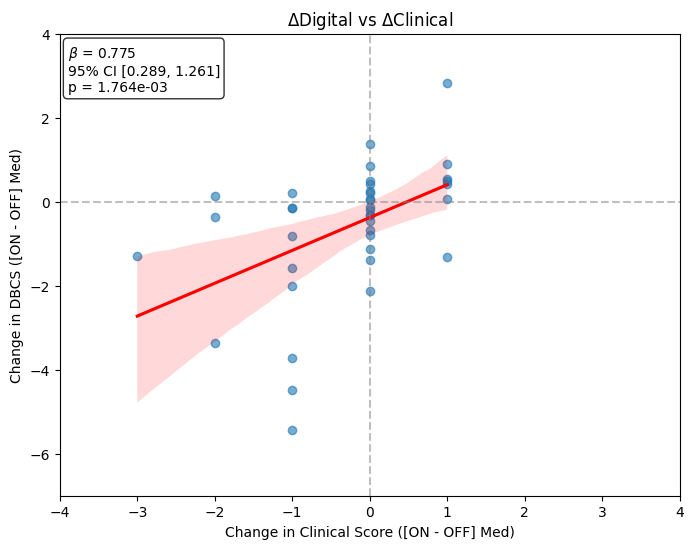

In [8]:
#plot the data
beta_ = ols_DBS.params['Delta_Item'] 
p_ = ols_DBS.pvalues['Delta_Item'] 
ci_ = ols_DBS.conf_int().loc['Delta_Item'].values 


# 5. Plotting
fig, ax = plt.subplots(1,1,figsize=(8, 6))
sns.regplot(x='Delta_Item', y='Delta_Final', data=diff_df, 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

# Add Zero-Lines for context
plt.axhline(0, color='gray', ls='--', alpha=0.5)
plt.axvline(0, color='gray', ls='--', alpha=0.5)

# Add Results Box

plt.text( -3.9, 3.75, f"$\\beta$ = {beta_:.3f}\n" f"95% CI [{ci_[0]:.3f}, {ci_[1]:.3f}]\n" f"p = {p_:.3e}",  va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 


plt.title('$\Delta$Digital vs $\Delta$Clinical')
plt.xlabel('Change in Clinical Score ([ON - OFF] Med)')
plt.ylabel('Change in DBCS ([ON - OFF] Med)')
plt.ylim([-7,4])
plt.xlim([-4,4])
plt.show()

Final_Score effect size (paired Cohen's dz): -0.379


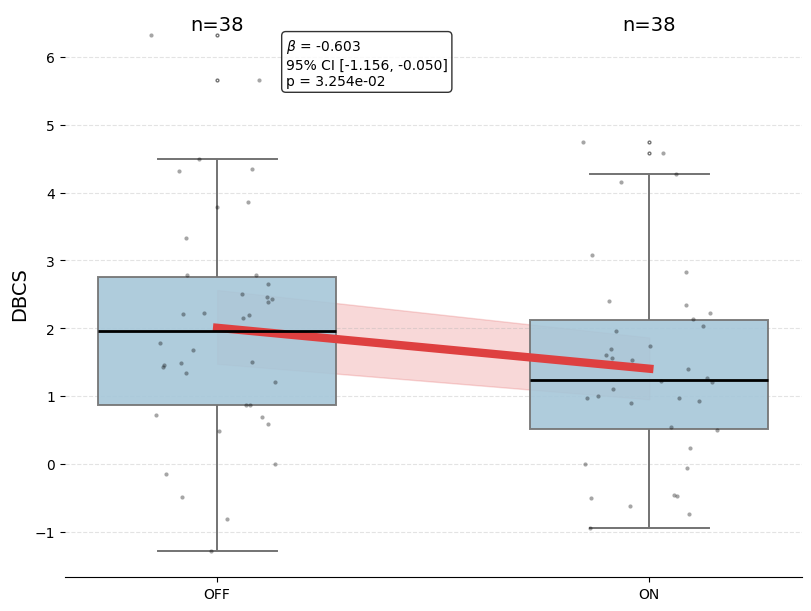

In [9]:
# Professional box plots for ON vs OFF (Item and Final Score)

finalScores = [
            'Movement_Vigor_Score',
            'SequenceEffect_Score',
            'Movement_Irregularity_Score',
            'Timming_Score',
            'Pauses_and_Hesitations_Score',
            # 'Timming_Irregularity_Score',
            'Final_Score',
        ]
var= finalScores[5]
plot_df =DBS_ON_OFF[['DBS', var]].copy()
order = ['OFF', 'ON']
palette = {'OFF': '#9ecae1', 'ON': '#9ecae1'}

fig, axes = plt.subplots(1, 1, figsize=(8, 6),  constrained_layout=True)
sns.boxplot(
    data=plot_df, x='DBS', y = var, order=order, ax=axes, hue='DBS',
    palette=palette, width=0.55, linewidth=1.4, fliersize=2,
    boxprops=dict(alpha=0.9),
    medianprops=dict(color='black', linewidth=2)
)
sns.stripplot(
    data=plot_df, x='DBS', y=var, order=order, ax=axes,
    color='black', size=3, alpha=0.35, jitter=0.16
)

sns.lineplot(data=plot_df, x='DBS', y=var, color="#DE4040", lw=6)


# axes.set_title('ON vs OFF Comparison', fontsize=16, weight='bold')
axes.set_xlabel('')
# axes.set_ylabel(f'UPDRS Item 3.4 Score', fontsize=14)
axes.set_ylabel(f'DBCS', fontsize=14)
axes.grid(axis='y', linestyle='--', alpha=0.35)
sns.despine(ax=axes, left=True)

# sample size labels
counts = plot_df.groupby('DBS')[var].count()
y0, y1 = axes.get_ylim()
y_text = y1 - 0.01 * (y1 - y0)
for i, dbs in enumerate(order):
    axes.text(i, y_text, f"n={counts.get(dbs, 0)}", ha='center', va='top', fontsize=14)
# fig.suptitle('ON vs OFF Comparison', fontsize=16, weight='bold')




dbs_df = DBS_ON_OFF.copy()
dbs_df['DBS'] = pd.Categorical(dbs_df['DBS'], categories=['OFF', 'ON'], ordered=True)
d = dbs_df[['SubjectID', 'DBS', var]].dropna().copy()


model= sm.OLS.from_formula( f"{var} ~ C(DBS, Treatment(reference='OFF'))", data=d ).fit(cov_type='cluster', cov_kwds={'groups': d['SubjectID']}) 
beta = model.params["C(DBS, Treatment(reference='OFF'))[T.ON]"] 
p = model.pvalues["C(DBS, Treatment(reference='OFF'))[T.ON]"] 
ci = model.conf_int().loc["C(DBS, Treatment(reference='OFF'))[T.ON]"].values 

axes.text( 0.3, 0.95, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3e}", transform=axes.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# Paired effect size (appropriate for repeated ON/OFF within each Subject)
paired = DBS_ON_OFF.pivot(index='Subject', columns='DBS', values=var).dropna(subset=['OFF', 'ON'])
off_vals = paired['OFF']
on_vals = paired['ON']
diff = on_vals - off_vals

# Use rank-biserial correlation for ordinal/discrete outcomes (e.g., UPDRS Item),
# otherwise use paired Cohen's dz for continuous outcomes.
if pd.api.types.is_integer_dtype(DBS_ON_OFF[var]) or DBS_ON_OFF[var].nunique() <= 7:
    nz = diff[diff != 0]
    if len(nz) == 0:
        print(f"{var} effect size (rank-biserial): 0.000 (all paired differences are zero)")
    else:
        ranks = stats.rankdata(np.abs(nz))
        w_pos = ranks[nz > 0].sum()
        w_neg = ranks[nz < 0].sum()
        r_rb = (w_pos - w_neg) / (w_pos + w_neg)
        print(f"{var} effect size (paired rank-biserial r): {r_rb:.3f}")
else:
    cohens_dz = diff.mean() / diff.std(ddof=1)
    print(f"{var} effect size (paired Cohen's dz): {cohens_dz:.3f}")
# plt.tight_layout() 
plt.show() 


Item effect size (paired rank-biserial r): -0.433


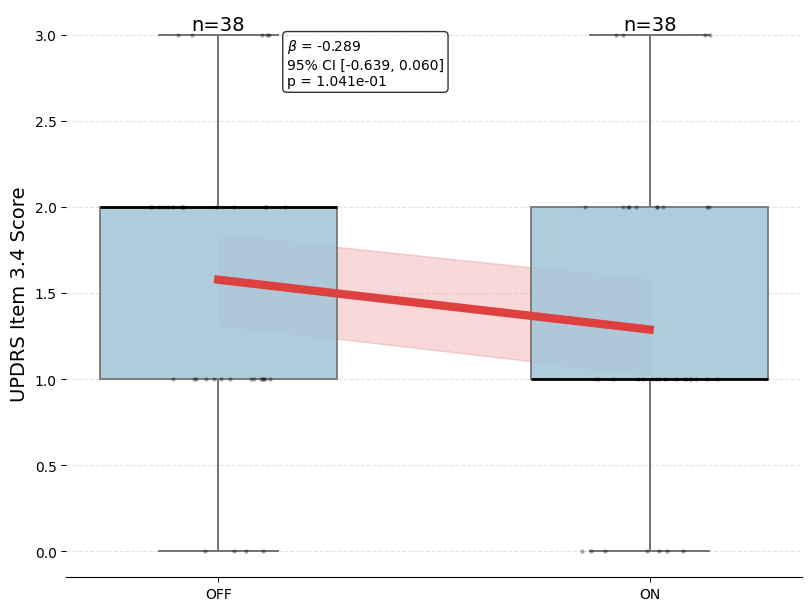

In [10]:
# Professional box plots for ON vs OFF (Item)

var= 'Item'
plot_df = DBS_ON_OFF[['DBS', var]].copy()
order = ['OFF', 'ON']
palette = {'OFF': '#9ecae1', 'ON': '#9ecae1'}

fig, axes = plt.subplots(1, 1, figsize=(8, 6),  constrained_layout=True)
sns.boxplot(
    data=plot_df, x='DBS', y = var, order=order, ax=axes, hue='DBS',
    palette=palette, width=0.55, linewidth=1.4, fliersize=2,
    boxprops=dict(alpha=0.9),
    medianprops=dict(color='black', linewidth=2)
)
sns.stripplot(
    data=plot_df, x='DBS', y=var, order=order, ax=axes,
    color='black', size=3, alpha=0.35, jitter=0.16
)

sns.lineplot(data=plot_df, x='DBS', y=var, color="#DE4040", lw=6)


# axes.set_title('ON vs OFF Comparison', fontsize=16, weight='bold')
axes.set_xlabel('')
axes.set_ylabel(f'UPDRS Item 3.4 Score', fontsize=14)
axes.grid(axis='y', linestyle='--', alpha=0.35)
sns.despine(ax=axes, left=True)

# sample size labels
counts = plot_df.groupby('DBS')[var].count()
y0, y1 = axes.get_ylim()
y_text = y1 - 0.01 * (y1 - y0)
for i, dbs in enumerate(order):
    axes.text(i, y_text, f"n={counts.get(dbs, 0)}", ha='center', va='top', fontsize=14)
# fig.suptitle('ON vs OFF Comparison', fontsize=16, weight='bold')




dbs_df = DBS_ON_OFF.copy()
dbs_df['DBS'] = pd.Categorical(dbs_df['DBS'], categories=['OFF', 'ON'], ordered=True)
d = dbs_df[['SubjectID', 'DBS', var]].dropna().copy()


model= sm.OLS.from_formula( f"{var} ~ C(DBS, Treatment(reference='OFF'))", data=d ).fit(cov_type='cluster', cov_kwds={'groups': d['SubjectID']}) 
beta = model.params["C(DBS, Treatment(reference='OFF'))[T.ON]"] 
p = model.pvalues["C(DBS, Treatment(reference='OFF'))[T.ON]"] 
ci = model.conf_int().loc["C(DBS, Treatment(reference='OFF'))[T.ON]"].values 

axes.text( 0.3, 0.95, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3e}", transform=axes.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# Paired effect size (appropriate for repeated ON/OFF within each Subject)
paired = DBS_ON_OFF.pivot(index='Subject', columns='DBS', values=var).dropna(subset=['OFF', 'ON'])
off_vals = paired['OFF']
on_vals = paired['ON']
diff = on_vals - off_vals

# Use rank-biserial correlation for ordinal/discrete outcomes (e.g., UPDRS Item),
# otherwise use paired Cohen's dz for continuous outcomes.
if pd.api.types.is_integer_dtype(DBS_ON_OFF[var]) or DBS_ON_OFF[var].nunique() <= 7:
    nz = diff[diff != 0]
    if len(nz) == 0:
        print(f"{var} effect size (rank-biserial): 0.000 (all paired differences are zero)")
    else:
        ranks = stats.rankdata(np.abs(nz))
        w_pos = ranks[nz > 0].sum()
        w_neg = ranks[nz < 0].sum()
        r_rb = (w_pos - w_neg) / (w_pos + w_neg)
        print(f"{var} effect size (paired rank-biserial r): {r_rb:.3f}")
else:
    cohens_dz = diff.mean() / diff.std(ddof=1)
    print(f"{var} effect size (paired Cohen's dz): {cohens_dz:.3f}")
# plt.tight_layout() 
plt.show() 
